# ISL Translator — Optimised Training Pipeline
**Dataset:** 26 classes × 1200 images = 31,200 total images

### Optimisations vs original
| Parameter | Original | Optimised | Reason |
|---|---|---|---|
| `BATCH_SIZE` | 16 | **64** | Reduces steps/epoch from ~1,560 → ~390 (~4× faster per epoch) |
| `PHASE1_EPOCHS` | 30 | **20** | Larger dataset converges faster; early-stopping catches the plateau |
| `PHASE1_LR` | 8e-4 | **1e-3** | Slightly higher LR is safe with bigger batches |
| `PHASE2_EPOCHS` | 10 | **15** | More data justifies more fine-tuning steps |
| `FINE_TUNE_LR` | 1e-6 | **5e-5** | 1e-6 barely moved weights; 25k images can use a real LR |
| `UNFREEZE_N` | 10 | **30** | Larger dataset benefits from tuning deeper MobileNetV2 features |
| ES patience | 8 | **5** | Plateau detection is faster with more data per epoch |
| `workers` | 1 | **8** | Parallel CPU prefetch keeps compute fed |
| `use_multiprocessing` | False | **True** | True parallelism in Keras data generators |

[Train] CPU mode — 12 cores.

[Train] Scanning dataset …
[Utils] Found 26 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Found 10400 images belonging to 26 classes.
Found 2600 images belonging to 26 classes.
[Utils] Train samples : 10400
[Utils] Val samples   : 2600
[Utils] Label map saved → C:\Users\kkani\Documents\py files\ISL\word\label_map.json
[Train] Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
[Train] Batch size          : 64
[Train] Steps/epoch (train) : 163
[Train] Steps/epoch (val)   : 41

[Train] Computing class weights …

[Train] Building model …


Model: "ISL_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,627,290 (10.02 MB)

 Trainable params: 366,746 (1.40 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


[Model] Trainable params     : 366,746
[Model] Non-trainable params : 2,260,544

[Train] ══ Preprocessing sanity check ══
  Generator rescale : 1/255  →  images in [0, 1]
  Model preprocess  : NONE   (preprocess_input removed from word_model.py)
  MobileNetV2 input : [0, 1] — consistent at train & inference

PHASE 1: Train head  (up to 20 epochs, LR=0.001)
         Best model → C:\Users\kkani\Documents\py files\ISL\word\isl_phase1_best.keras
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8102 - loss: 0.7513
Epoch 1: val_accuracy improved from None to 0.98808, saving model to C:\Users\kkani\Documents\py files\ISL\word\isl_phase1_best.keras

Epoch 1: finished saving model to C:\Users\kkani\Documents\py files\ISL\word\isl_phase1_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 602s 4s/step - accuracy: 0.9425 - loss: 0.2303 - val_accuracy: 0.9881 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9962 - loss: 0.0150
Epoch 2

c:\Users\kkani\Documents\py files\ISL\.conda\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Model] Unfroze top 30 base layers for fine-tuning.
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9910 - loss: 0.0339
Epoch 1: val_accuracy improved from None to 0.98808, saving model to C:\Users\kkani\Documents\py files\ISL\word\isl_best_model.keras

Epoch 1: finished saving model to C:\Users\kkani\Documents\py files\ISL\word\isl_best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9956 - loss: 0.0156 - val_accuracy: 0.9881 - val_loss: 0.0476 - learning_rate: 5.0000e-05
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9989 - loss: 0.0036
Epoch 2: val_accuracy improved from 0.98808 to 0.99000, saving model to C:\Users\kkani\Documents\py files\ISL\word\isl_best_model.keras

Epoch 2: finished saving model to C:\Users\kkani\Documents\py files\ISL\word\isl_best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9900 - val_loss: 0.0562 - learning_rate: 5.0000e-05
Epoch 3/15
163/163 

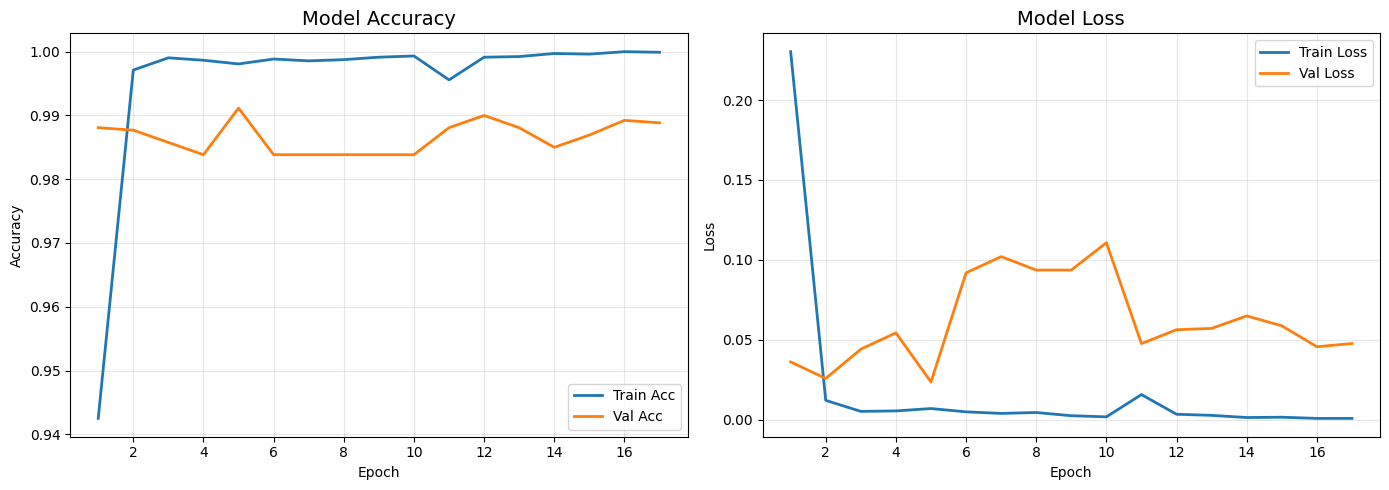

[Utils] Training plot saved → C:\Users\kkani\Documents\py files\ISL\word\plots\training_history.png

[Train] Loading final model from C:\Users\kkani\Documents\py files\ISL\word\isl_best_model.keras for evaluation …

[Train] Per-class accuracy on validation set:
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 774ms/step

  Letter      Correct    Total   Accuracy
  ----------------------------------------
  A               100      100     100.0%
  B               100      100     100.0%
  C               100      100     100.0%
  D               100      100     100.0%
  E               100      100     100.0%
  F               100      100     100.0%
  G               100      100     100.0%
  H               100      100     100.0%
  I               100      100     100.0%
  J               100      100     100.0%
  K               100      100     100.0%
  L               100      100     100.0%
  M               100      100     100.0%
  N               100      100     100.0%
  O               100 

In [4]:
"""
train.ipynb – ISL Translator Training Pipeline
Optimised for 26 classes × 1200 images/class (31,200 total)
"""

import os
import sys
sys.path.insert(0, "C:\\Users\\kkani\\Documents\\py files\\ISL")

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from word_model import build_model, unfreeze_top_layers, print_model_summary
from utils import (
    get_generators_from_directory,
    save_label_map, plot_training_history,
    MODEL_SAVE_PATH, IMG_SIZE
)

# ─────────────────────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────────────────────
DATASET_PATH     = r"C:\Users\kkani\Downloads\isl_word_mini"
BASE_DIR         = "C:\\Users\\kkani\\Documents\\py files\\ISL"
PHASE1_SAVE_PATH = os.path.join(BASE_DIR, "word\\isl_phase1_best.keras")

# ─────────────────────────────────────────────────────────────────────────────
# HYPER-PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────

# Batch size — passed directly into get_generators_from_directory().
# utils.py now accepts batch_size as an optional parameter; if omitted it
# falls back to the global BATCH_SIZE=16 constant.
# 64  → ~390 steps/epoch on 24,960 train images (was ~1,560 at batch=16)
# 128 → ~195 steps/epoch if your machine has ≥8 GB free RAM
BATCH_SIZE = 64

# Phase 1 — train classification head only (base frozen)
PHASE1_EPOCHS = 20          # was 30 — more data converges faster
PHASE1_LR     = 1e-3        # was 8e-4

# Phase 2 — fine-tune top N layers of the base model
PHASE2_EPOCHS  = 15         # was 10
FINE_TUNE_LR   = 5e-5       # was 1e-6 (far too conservative for 25k images)
UNFREEZE_N     = 30         # was 10

# Skip Phase 2 when Phase 1 accuracy is below this floor
PHASE2_MIN_ACC = 0.40

# Parallel data loading — keeps the compute unit fed between batches
DATA_WORKERS        = 8     # set to number of physical CPU cores (or half)
USE_MULTIPROCESSING = True


# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def configure_cpu():
    import multiprocessing
    n = multiprocessing.cpu_count()
    tf.config.threading.set_intra_op_parallelism_threads(n)
    tf.config.threading.set_inter_op_parallelism_threads(n)
    print(f"[Train] CPU mode — {n} cores.")


def compute_class_weights(train_gen, num_classes):
    import numpy as np
    from sklearn.utils.class_weight import compute_class_weight

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=train_gen.classes
    )
    return {i: w for i, w in enumerate(weights)}


def phase1_callbacks():
    os.makedirs(os.path.dirname(PHASE1_SAVE_PATH) or ".", exist_ok=True)
    return [
        ModelCheckpoint(
            filepath=PHASE1_SAVE_PATH,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
            mode="max"
        ),
        EarlyStopping(
            monitor="val_accuracy",
            patience=5,             # was 8 — plateau detected sooner with more data
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.4,
            patience=3,             # was 4
            min_lr=1e-7,
            verbose=1
        ),
    ]


def phase2_callbacks():
    os.makedirs(os.path.dirname(MODEL_SAVE_PATH) or ".", exist_ok=True)
    return [
        ModelCheckpoint(
            filepath=MODEL_SAVE_PATH,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
            mode="max"
        ),
        EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        ),
    ]


def get_best_val_accuracy(history) -> float:
    accs = history.history.get("val_accuracy", [])
    return max(accs) if accs else 0.0


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

def main():
    if not os.path.isdir(DATASET_PATH):
        print(f"[ERROR] Dataset not found:\n  {DATASET_PATH}")
        sys.exit(1)

    configure_cpu()

    # ── Data generators ───────────────────────────────────────────────────────
    print("\n[Train] Scanning dataset …")
    # batch_size is passed explicitly so generators use BATCH_SIZE=64 instead
    # of the global default of 16 defined in utils.py.
    # utils.py has been updated to accept this optional parameter.
    train_gen, val_gen, label_map, class_names, num_classes = \
        get_generators_from_directory(DATASET_PATH, batch_size=BATCH_SIZE)

    save_label_map(label_map)
    print(f"[Train] Classes ({num_classes}): {class_names}")
    print(f"[Train] Batch size          : {BATCH_SIZE}")
    print(f"[Train] Steps/epoch (train) : {len(train_gen)}")
    print(f"[Train] Steps/epoch (val)   : {len(val_gen)}")

    print("\n[Train] Computing class weights …")
    class_weights = compute_class_weights(train_gen, num_classes)

    # ── Build model ───────────────────────────────────────────────────────────
    # NOTE: build_model() must be called BEFORE any mixed-precision policy
    # is set (and mixed precision is skipped entirely here because this is a
    # CPU-only run — float16 ops are not accelerated on CPU and would
    # slow training down, not speed it up).
    print("\n[Train] Building model …")
    model, base_model = build_model(
        num_classes=num_classes,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        learning_rate=PHASE1_LR
    )
    print_model_summary(model)

    print("\n[Train] ══ Preprocessing sanity check ══")
    print("  Generator rescale : 1/255  →  images in [0, 1]")
    print("  Model preprocess  : NONE   (preprocess_input removed from word_model.py)")
    print("  MobileNetV2 input : [0, 1] — consistent at train & inference\n")

    # ══════════════════════════════════════════════════════════════════════════
    # Phase 1 — Train classification head only (base FROZEN)
    # ══════════════════════════════════════════════════════════════════════════
    print("=" * 60)
    print(f"PHASE 1: Train head  (up to {PHASE1_EPOCHS} epochs, LR={PHASE1_LR})")
    print(f"         Best model → {PHASE1_SAVE_PATH}")
    print("=" * 60)

    history1 = model.fit(
        train_gen,
        epochs=PHASE1_EPOCHS,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=phase1_callbacks(),
        verbose=1
    )

    phase1_best_acc = get_best_val_accuracy(history1)
    print(f"\n[Train] Phase 1 best val_accuracy : {phase1_best_acc:.4f}")

    # ══════════════════════════════════════════════════════════════════════════
    # Phase 2 — Fine-tune top N layers of the base model
    # ══════════════════════════════════════════════════════════════════════════
    history2 = None

    if phase1_best_acc < PHASE2_MIN_ACC:
        print(f"\n[Train] Phase 1 accuracy ({phase1_best_acc:.1%}) below "
              f"{PHASE2_MIN_ACC:.0%} threshold — skipping Phase 2.")
        import shutil
        shutil.copy2(PHASE1_SAVE_PATH, MODEL_SAVE_PATH)
    else:
        print("\n" + "=" * 60)
        print(f"PHASE 2: Fine-tune top {UNFREEZE_N} base layers")
        print(f"         LR={FINE_TUNE_LR}  |  max {PHASE2_EPOCHS} epochs")
        print("         Loading Phase 1 best weights …")
        print("=" * 60)

        # FIX: build a FRESH model and capture its own base_model reference.
        # The earlier `base_model` belongs to the Phase 1 model object; after
        # calling build_model() again we must use the NEW base_model2 so that
        # unfreeze_top_layers() modifies the layers that are actually embedded
        # in the Phase 2 model — not the stale Phase 1 object.
        #
        # Also removed the redundant tf.keras.models.load_model() call that
        # was present in the previous version — it was immediately overwritten
        # by build_model() on the very next line, achieving nothing.
        model2, base_model2 = build_model(
            num_classes=num_classes,
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            learning_rate=PHASE1_LR
        )
        model2.load_weights(PHASE1_SAVE_PATH)

        # Pass base_model2 — the base model embedded inside model2
        model2 = unfreeze_top_layers(
            model2, base_model2,
            num_layers_to_unfreeze=UNFREEZE_N,
            learning_rate=FINE_TUNE_LR
        )

        history2 = model2.fit(
            train_gen,
            epochs=PHASE2_EPOCHS,
            validation_data=val_gen,
            class_weight=class_weights,
            callbacks=phase2_callbacks(),
            verbose=1
        )

        phase2_best_acc = get_best_val_accuracy(history2)
        print(f"\n[Train] Phase 2 best val_accuracy : {phase2_best_acc:.4f}")

        if phase2_best_acc < phase1_best_acc:
            print(f"[Train] Phase 2 ({phase2_best_acc:.1%}) worse than "
                  f"Phase 1 ({phase1_best_acc:.1%}) — reverting to Phase 1 model.")
            import shutil
            shutil.copy2(PHASE1_SAVE_PATH, MODEL_SAVE_PATH)
        else:
            print(f"[Train] Phase 2 improved accuracy "
                  f"({phase1_best_acc:.1%} → {phase2_best_acc:.1%}).")

    # ── Merge histories & plot ────────────────────────────────────────────────
    class MergedHistory:
        def __init__(self, h1, h2):
            self.history = {
                k: h1.history[k] + (h2.history.get(k, []) if h2 else [])
                for k in h1.history
            }

    plot_training_history(MergedHistory(history1, history2))

    # ── Load final model for evaluation ──────────────────────────────────────
    print(f"\n[Train] Loading final model from {MODEL_SAVE_PATH} for evaluation …")
    final_model = tf.keras.models.load_model(MODEL_SAVE_PATH, compile=False)

    # ── Per-class accuracy on validation set ──────────────────────────────────
    print("\n[Train] Per-class accuracy on validation set:")
    val_gen.reset()
    preds        = final_model.predict(val_gen, verbose=1)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = val_gen.classes[:len(pred_classes)]

    print(f"\n  {'Letter':<10} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
    print("  " + "-" * 40)
    for i, name in enumerate(class_names):
        mask    = true_classes == i
        total   = mask.sum()
        correct = (pred_classes[mask] == i).sum()
        acc     = correct / total * 100 if total > 0 else 0
        flag    = "  ← LOW" if acc < 50 else ""
        print(f"  {name.upper():<10} {correct:>8} {total:>8} {acc:>9.1f}%{flag}")

    overall = (pred_classes == true_classes).mean() * 100
    print(f"\n  Overall val accuracy : {overall:.2f}%")

    if overall < 70:
        print("\n  [HINT] Accuracy lower than expected for 1200 imgs/class.")
        print("         Check data quality and class folder structure.")
    else:
        print("\n  [GOOD] Strong accuracy! Run python predict.py")

    print(f"\n  Final model → {MODEL_SAVE_PATH}")
    print("  Run  python predict.py  to start live detection.\n")


if __name__ == "__main__":
    main()
